In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
from sklearn.decomposition import PCA
from scipy.sparse import csr_matrix
from tqdm import tqdm


In [12]:
sc_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data.h5ad")
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)
print("Shape of combined_cell_types", combined_cell_types.shape)
envi_latent_st = st_ad.obsm['envi_latent']
envi_latent_sc = sc_ad.obsm['envi_latent']

print(f"st_ad envi_latent shape: {envi_latent_st.shape}")
print(f"sc_ad envi_latent shape: {envi_latent_sc.shape}")
combined_envi_latent = np.concatenate([envi_latent_sc, envi_latent_st], axis=0)
print(combined_envi_latent.shape)
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)



Shape of combined_cell_types (25932,)
st_ad envi_latent shape: (18516, 512)
sc_ad envi_latent shape: (7416, 512)
(25932, 512)


In [13]:
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)

n_components = 50
pca = PCA(n_components=n_components)
envi_pca = pca.fit_transform(combined_envi_latent)
print("Reduced shape:", envi_pca.shape)

Reduced shape: (25932, 50)


In [14]:
# Flatten the (64, 64) matrices into 1D vectors
st_covet_sqrt_flat = st_ad.obsm["COVET_SQRT"].reshape(st_ad.shape[0], -1)
sc_covet_sqrt_flat = sc_ad.obsm["COVET_SQRT"].reshape(sc_ad.shape[0], -1)

covet_sqrt_combined = np.concatenate([st_covet_sqrt_flat, sc_covet_sqrt_flat], axis=0)
print("Shape after flattening: ", covet_sqrt_combined.shape)
covet_pca = pca.fit_transform(covet_sqrt_combined)
print("Reduced shape:", covet_pca.shape)

Shape after flattening:  (25932, 4096)
Reduced shape: (25932, 50)


In [16]:
combined_matrix=np.concatenate([covet_pca, envi_pca], axis=1)
print(combined_matrix.shape)

(25932, 100)


In [17]:
adata=ad.AnnData(X=combined_matrix)

# save this adata in h5ad format in a file name e_pca_combined
adata.write_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/e_pca_combined.h5ad")
adata.obs["cell_type"] = combined_cell_types
adata.obsm["combined_matrix"] = combined_matrix
print(adata)

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    obsm: 'combined_matrix'


         Falling back to preprocessing with `sc.pp.pca` and default params.


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


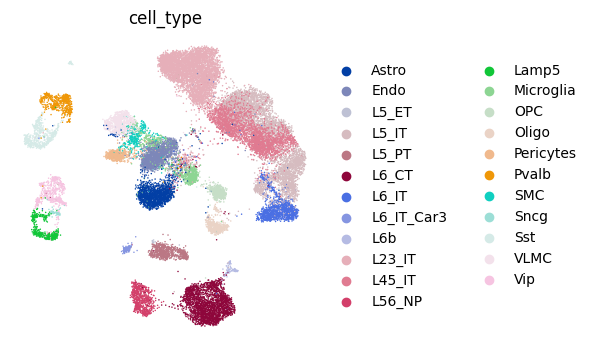

In [18]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type'], frameon=False)

In [19]:
adata

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    uns: 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'combined_matrix', 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'

In [4]:
adata_metacells= ad.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/Meta_A/save/metaA_run_100metacell_ids.h5ad")

In [20]:
if list(adata.obs_names) == list(adata_metacells.obs_names):
    print("Cell observation names match and are in order.")
else:
    print("WARNING: Cell observation names do NOT match or are not in the same order!")
    print("You may need to reorder one of the AnnData objects based on obs_names.")
    # Example of reordering if needed (use with caution):
    # common_cells = adata_original.obs_names.intersection(adata_metacells.obs_names)
    # adata_original = adata_original[common_cells, :]
    # adata_metacells = adata_metacells[common_cells, :]
    # Or, if you are certain adata_metacells.obs_names is a subset and in the correct order relative to a slice of adata_original:
    # adata_original = adata_original[adata_metacells.obs_names, :]

Cell observation names match and are in order.


In [21]:
adata.obs['metacell'] = adata_metacells.obs['metacell'].astype('category')

In [22]:
adata

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type', 'metacell'
    uns: 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'combined_matrix', 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'

In [5]:
adata_metacells

AnnData object with n_obs × n_vars = 25932 × 64
    obs: 'metacell'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [11]:
adata_metacells.obs['metacell']

0        77
1        61
2        24
3        47
4        34
         ..
25927    83
25928    17
25929    99
25930    55
25931    80
Name: metacell, Length: 25932, dtype: category
Categories (100, object): ['0', '1', '2', '3', ..., '96', '97', '98', '99']

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


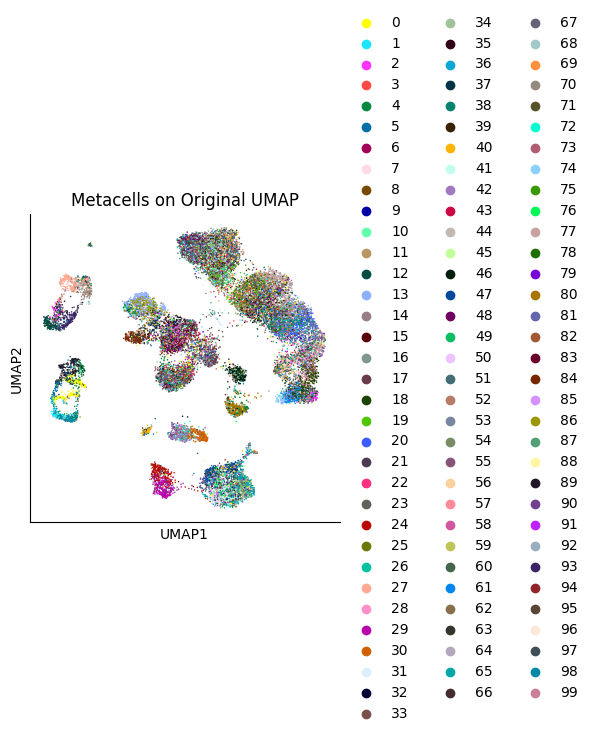

In [24]:
import matplotlib.pyplot as plt

# Assuming 'X_umap' is your embedding in adata_original
# If you don't have a UMAP for adata_original, calculate it first:
# sc.pp.neighbors(adata_original, use_rep='X_pca') # or another representation
# sc.tl.umap(adata_original)

sc.pl.umap(adata,
            color='metacell',
            
            title='Metacells on Original UMAP',
            show=False) # Use show=False if you want to save it

plt.savefig('original_umap_with_metacells.png', dpi=300)
plt.show() # Or plt.show() if you want to display it interactively

In [6]:
sc_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data.h5ad")
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)
print("Shape of combined_cell_types", combined_cell_types.shape)

Shape of combined_cell_types (25932,)


In [7]:
adata_metacells.obs["cell_type"] = combined_cell_types


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


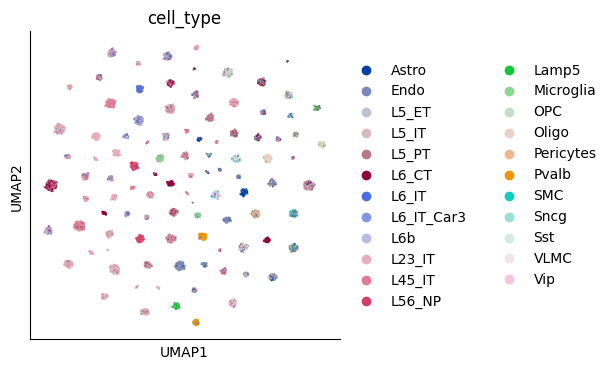

In [10]:
#plot the umap 
sc.pl.umap(adata_metacells, color=['cell_type'],  size=5, alpha=0.5)

Cell observations seem to match.
Plotting individual cells colored by metacell...
Calculating metacell centroids...
Plotting metacell centroids...


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/var/folders/d4/bgr0tr5d43z2xmtq5hk3s4n00000gn/T/ipykernel_83049/1548233509.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metacell_centroids = umap_coords.groupby('metacell')[['UMAP1', 'UMAP2']].mean()

Plot saved to original_umap_with_metacell_centroids.png


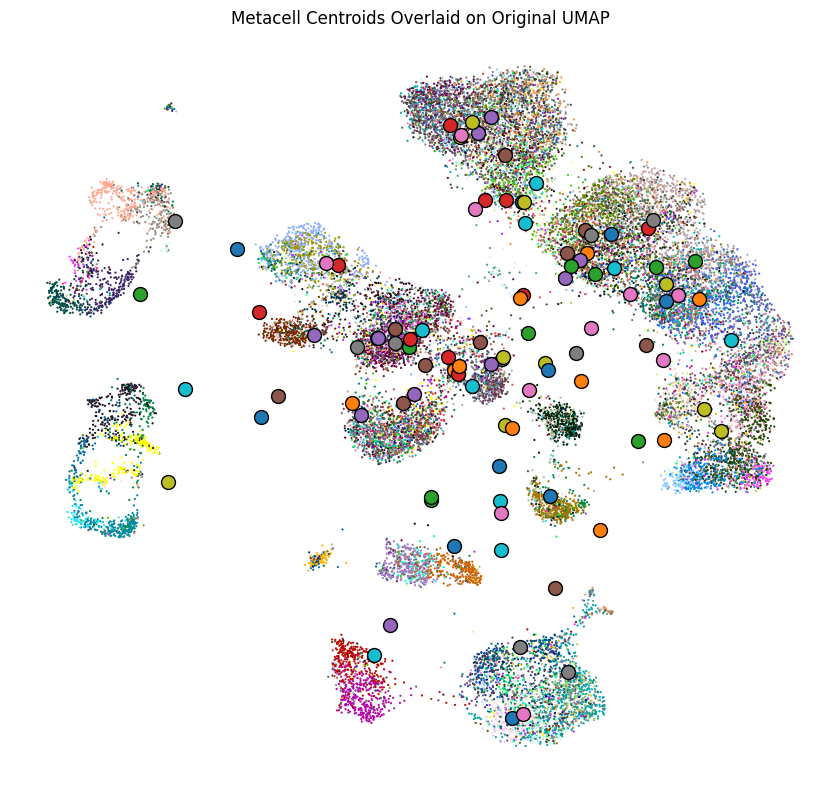

Plotting only metacell centroids...
Too many metacells for a clear legend on the centroids-only plot.
Plot saved to metacell_centroids_only_umap.png


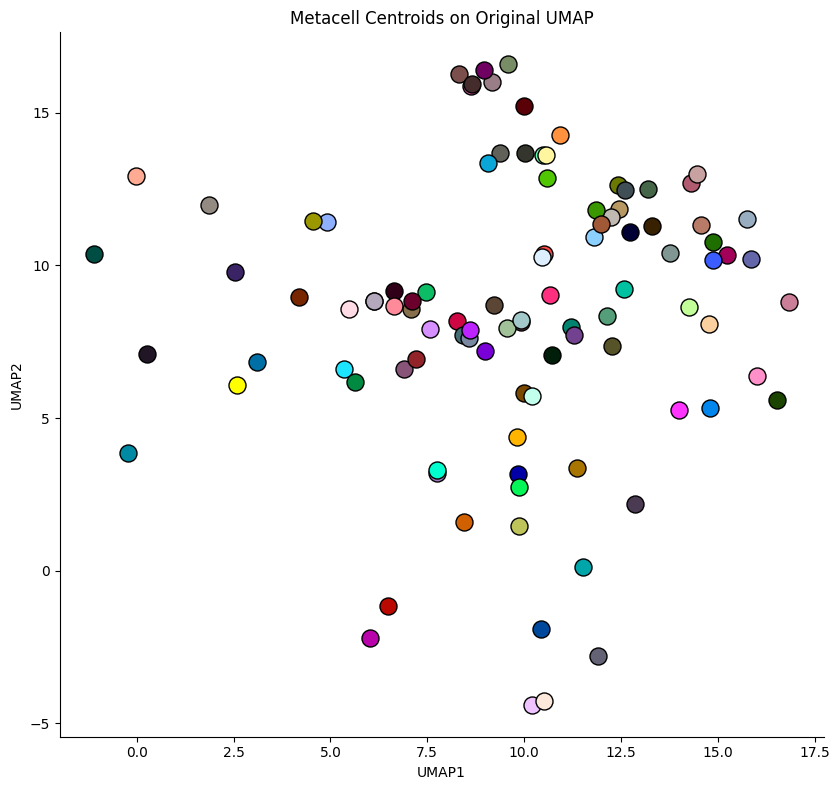

In [25]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Make sure numpy is imported



# --- Sanity Check and Alignment ---
# (Same as before - crucial for correct mapping)
if adata.n_obs != adata_metacells.n_obs:
    print(f"Warning: Number of observations differ...") # Truncated for brevity, use full check
    # Attempt alignment (as in previous response)
    # ...
    adata = adata[adata_metacells.obs_names, :].copy() # Example alignment
    if adata.n_obs != adata_metacells.n_obs:
         print("Error: Alignment failed.")
         exit()
elif not adata.obs_names.equals(adata_metacells.obs_names):
    print("Warning: Observation names are not identical or not in the same order.")
    try:
        adata = adata[adata_metacells.obs_names, :].copy()
    except KeyError:
        print("Error: Could not re-index adata.")
        exit()
else:
    print("Cell observations seem to match.")

# --- Transfer metacell IDs ---
if 'metacell' not in adata_metacells.obs:
    print("Error: 'metacell' column not found in adata_metacells.obs.")
    exit()
adata.obs['metacell'] = adata_metacells.obs['metacell'].astype('category')

# --- Ensure UMAP embedding exists in adata ---
if 'X_umap' not in adata.obsm:
    print("UMAP embedding ('X_umap') not found. Please compute it first.")
    # Attempt to compute UMAP (as in previous response)
    # ... (add UMAP computation logic here if needed) ...
    if 'X_pca' in adata.obsm:
        sc.pp.neighbors(adata, use_rep='X_pca')
        sc.tl.umap(adata)
    # Add other fallbacks if necessary
    if 'X_umap' not in adata.obsm:
        print("Failed to compute UMAP.")
        exit()

# --- Plot 1: Individual cells colored by metacell (what you currently have) ---
print("Plotting individual cells colored by metacell...")
fig, ax = plt.subplots(figsize=(10, 8)) # Create a figure and an axes
sc.pl.umap(adata,
            color='metacell',
            legend_loc=None, # We'll handle legend differently or omit for overlay
            frameon=False,
            title='Individual Cells Colored by Metacell',
            show=False,
            ax=ax, # Pass the axes to scanpy
            s=10) # s is the marker size for individual cells, adjust as needed

# --- Calculate Metacell Centroids ---
print("Calculating metacell centroids...")
# Create a DataFrame with UMAP coordinates and metacell assignments
umap_coords = pd.DataFrame(adata.obsm['X_umap'], columns=['UMAP1', 'UMAP2'])
umap_coords['metacell'] = adata.obs['metacell'].values

# Calculate the mean UMAP coordinates for each metacell
metacell_centroids = umap_coords.groupby('metacell')[['UMAP1', 'UMAP2']].mean()

# --- Plot 2: Overlay Metacell Centroids ---
print("Plotting metacell centroids...")

# Get the same colors scanpy uses for the metacells if possible
# If you have many metacells, generating a distinct color map is better.
# For simplicity, we'll use a generic scatter plot. Scanpy's color generation can be complex.

# Create a color map for the metacells if you want consistency
unique_metacells = adata.obs['metacell'].cat.categories
# colors = plt.cm.get_cmap('viridis', len(unique_metacells)) # Or 'tab20', 'tab10' etc.
# Or use scanpy's default palette if available from the previous plot (can be tricky)

# Plotting centroids on the *same axes* as the individual cell plot
for i, mc_id in enumerate(metacell_centroids.index):
    ax.scatter(metacell_centroids.loc[mc_id, 'UMAP1'],
               metacell_centroids.loc[mc_id, 'UMAP2'],
               s=100,  # Size of the metacell dots
               # color=colors(i), # Use this if you defined a colormap
               label=mc_id if i < 15 else None, # Label a few for legend, avoids clutter
               edgecolor='black', # Add an edge to make them stand out
               linewidth=1,
               zorder=3) # Ensure centroids are plotted on top

ax.set_title('Metacell Centroids Overlaid on Original UMAP')
if len(unique_metacells) < 15 : # Add legend if not too many metacells
    ax.legend(title='Metacell ID', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend if it's outside
plt.savefig('original_umap_with_metacell_centroids.png', dpi=300)
print("Plot saved to original_umap_with_metacell_centroids.png")
plt.show()


# --- Alternative: Plot only metacell centroids ---
print("Plotting only metacell centroids...")
fig_centroids_only, ax_centroids_only = plt.subplots(figsize=(10, 8))
# Get colors for metacells. You might need to define your own palette for consistency.
# If adata.uns['metacell_colors'] exists from a previous sc.pl.umap call, use that.
# Otherwise, create a new palette.
palette = None
if 'metacell_colors' in adata.uns and len(adata.uns['metacell_colors']) >= len(metacell_centroids.index):
    palette = {mc_id: adata.uns['metacell_colors'][i] for i, mc_id in enumerate(adata.obs['metacell'].cat.categories) if mc_id in metacell_centroids.index}

for i, mc_id in enumerate(metacell_centroids.index):
    color_val = palette.get(mc_id) if palette else None # Use palette color if available
    ax_centroids_only.scatter(metacell_centroids.loc[mc_id, 'UMAP1'],
                              metacell_centroids.loc[mc_id, 'UMAP2'],
                              s=150, # Size of the metacell dots
                              label=mc_id,
                              edgecolor='black',
                              linewidth=1,
                              color=color_val) # Apply color

ax_centroids_only.set_xlabel('UMAP1')
ax_centroids_only.set_ylabel('UMAP2')
ax_centroids_only.set_title('Metacell Centroids on Original UMAP')
if len(metacell_centroids.index) < 30: # Show legend if not too cluttered
    ax_centroids_only.legend(title='Metacell ID', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
else:
    print("Too many metacells for a clear legend on the centroids-only plot.")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('metacell_centroids_only_umap.png', dpi=300)
print("Plot saved to metacell_centroids_only_umap.png")
plt.show()